In [ ]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from tqdm import tqdm


sc.set_figure_params(dpi=80)
plt.rcParams['axes.grid'] = False

from sklearn.neighbors import radius_neighbors_graph
import networkx as nx
import scipy.sparse.csgraph


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))

from general_utils import ismember, grep, grep_exclude
from anndata_utils import random_adata_subset


In [ ]:
def plot_individual_category(adata, coord_name, obs_name, selected_values, condition_colors, alpha = 1, s=0.1, frameon=True, figsize = [5,5]):
    x = adata.obsm[coord_name][:,0]
    y = adata.obsm[coord_name][:,1]
    conditions = adata.obs[obs_name]
    colors = np.array([condition_colors[x] if x != None else 'lightgray' for x in ismember(conditions, selected_values)[0]])    
    subcells = ismember(conditions, selected_values)[1]
    point_order = np.random.permutation(np.sum(subcells))
    f, ax = plt.subplots(1,1,figsize=figsize, dpi=150)
    ax.scatter(x,y, facecolor='black', edgecolor=None, linewidth=0, s=s*20, alpha = 1)
    ax.scatter(x,y, facecolor='white', edgecolor=None, linewidth=0, s=s*10, alpha = 1)
    ax.scatter(x,y, facecolor='lightgray', edgecolor=None, linewidth=0, s=s, alpha = 1)
    ax.scatter(x[subcells][point_order],y[subcells][point_order], facecolor=colors[subcells][point_order], edgecolor=None, linewidth=0, s=s*2.5, alpha = alpha)
    if not frameon:
        ax.axis(False)
    ax.grid(False)

In [ ]:
def get_compiled_adata_subset(selected_tier, selected_subset, use_log, explained_var, umap_n_neighbors, cluster_n_neighbors, selected_layer = 'raw_in_nucleus', umap_min_dist = 0.05):
    dataset_prefix = "adata_" + selected_tier + "_SUBSET_%s_LAYER_%s_LOG_%s" % (selected_subset, selected_layer, use_log)
    file_prefix = "%s_EXPLAINEDVAR_%d_KNN_%s" % (dataset_prefix, int(explained_var * 100), "%d")
    
    adata_base_file = os.path.join(adata_base_output_path, dataset_prefix + ".h5ad")
    obs_file = os.path.join(obs_output_path,file_prefix % (cluster_n_neighbors) + "__obs.h5ad" )
    umap_file = os.path.join(umap_output_path,file_prefix % (umap_n_neighbors) + "_MINDIST_%d__umap.csv.gz" % int(umap_min_dist * 100))
    knn_file = os.path.join(knn_output_path,file_prefix % (cluster_n_neighbors) + "__knn.h5ad" )
    output_template = dataset_prefix + "_EXPLAINEDVAR_%d_CLUSTERKNN_%d_UMAPKNN_%d_MINDIST_%d__compiled.h5ad"
    output_file = os.path.join(compiled_output_path, output_template % (int(explained_var * 100), cluster_n_neighbors, umap_n_neighbors, int(umap_min_dist * 100)))

    print("Reading counts file")
    adata = sc.read_h5ad(adata_base_file)
    print("Reading obs file")
    obs = sc.read_h5ad(obs_file)
    print("Reading umap file")
    umap = pd.read_csv(umap_file, index_col = 0)
    
    adata.obsm['X_umap'] = umap.to_numpy()
    for colname in obs.obs.columns:
        adata.obs[colname] = pd.Categorical(obs.obs[colname])

    print("Loading master annotations")
    master_obs = sc.read_h5ad(os.path.join(updated_obs_output_path, "adata_tier0_SUBSET_all_LAYER_raw_in_nucleus_LOG_False_EXPLAINEDVAR_75_KNN_30__obs.h5ad"))
    master_obs = master_obs[adata.obs_names,:].copy()
    for my_obs in master_obs.obs.columns:
        adata.obs[my_obs] = master_obs.obs[my_obs].copy()    
    return(adata, output_file)


In [ ]:
output_path = '../xenium_preprocessing_outputs'

knn_output_path = os.path.join(output_path, 'knn')
pca_output_path = os.path.join(output_path, 'pca')
umap_output_path = os.path.join(output_path, 'umap')
adata_base_output_path = os.path.join(output_path, 'adata_base')
obs_output_path = os.path.join(output_path, 'obs')
updated_obs_output_path = os.path.join(output_path, 'obs_updated')
compiled_output_path = os.path.join(output_path, 'compiled')
spatialnhood_output_path = os.path.join(output_path, 'spatial_neighborhood')


In [ ]:
selected_tier = 'tier0'
selected_subset = 'all'
use_log = False
explained_var = 0.75
umap_n_neighbors = 10
cluster_n_neighbors = 30
selected_layer = 'raw_in_nucleus'
umap_min_dist = 0.1
adata_all, compiled_output_file = get_compiled_adata_subset(selected_tier = selected_tier, selected_subset = selected_subset, use_log = use_log, explained_var = explained_var, umap_n_neighbors = umap_n_neighbors, cluster_n_neighbors = cluster_n_neighbors, selected_layer = selected_layer, umap_min_dist = umap_min_dist)


Import spatial distance file

In [ ]:
selected_radius = 60
adata_neighborhood = sc.read_h5ad(os.path.join(spatialnhood_output_path, "adata_tier0_SUBSET_all_MODE_circle_OUTER_" + str(selected_radius) + "_INNER_None__spatialnhood.h5ad"))


Verify that adata_neighborhood and adata_all are in the same order

In [ ]:
np.sum([x == y for x,y in zip(adata_all.obs_names, adata_neighborhood.obs_names)])/adata_all.n_obs

np.float64(1.0)

Define premalignant_environment as cells tha lie within the selected radius of an epithelial cell

In [ ]:
premalignant_environment = np.ravel(adata_neighborhood.obsp['spatial_neighborhood'][adata_all.obs['cell_type_0'].to_numpy() == 'Epithelial',:].sum(axis=0)) > 0

In [ ]:
np.sum(premalignant_environment) / adata_all.n_obs

np.float64(0.840168708329411)

In [ ]:
adata_all.obs['premalignant_environment'] = pd.Categorical(premalignant_environment)

In [ ]:
adata_sub = adata_all[adata_all.obs['slide_id'] == "JR-sp-19-09",:].copy()

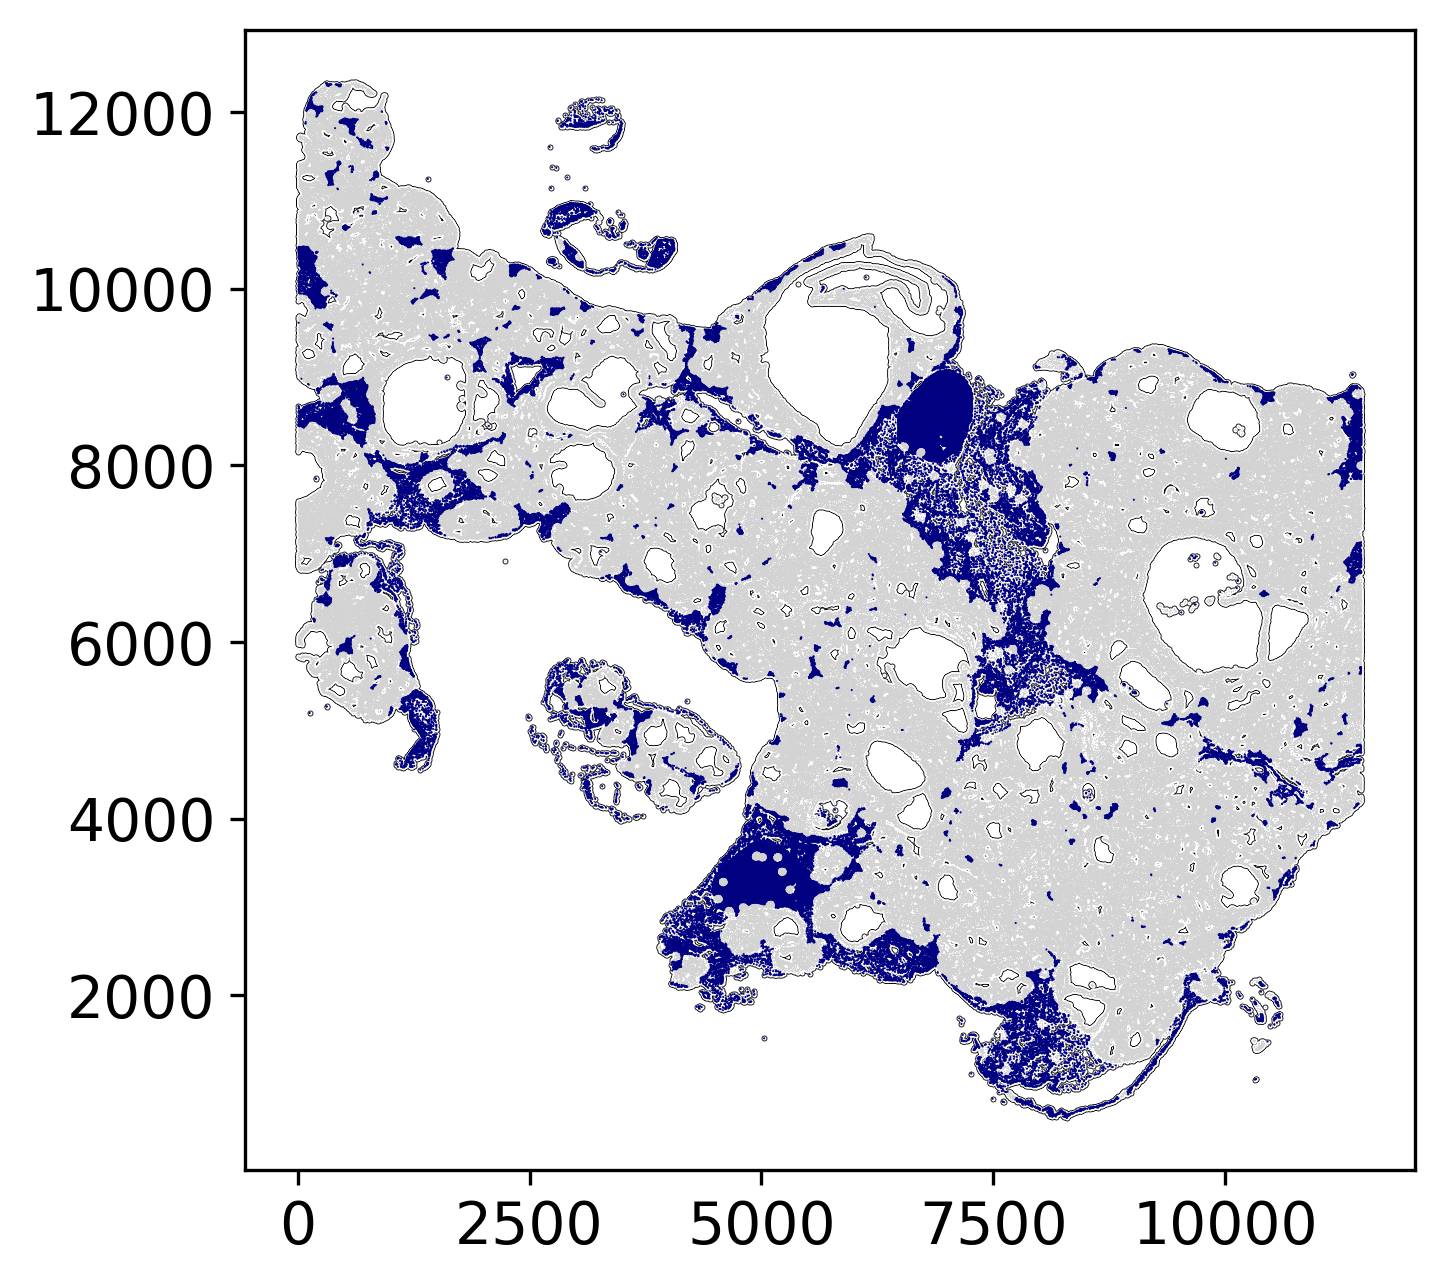

In [ ]:
plot_individual_category(adata_sub, "X_spatial", "premalignant_environment", [False], ["navy"])

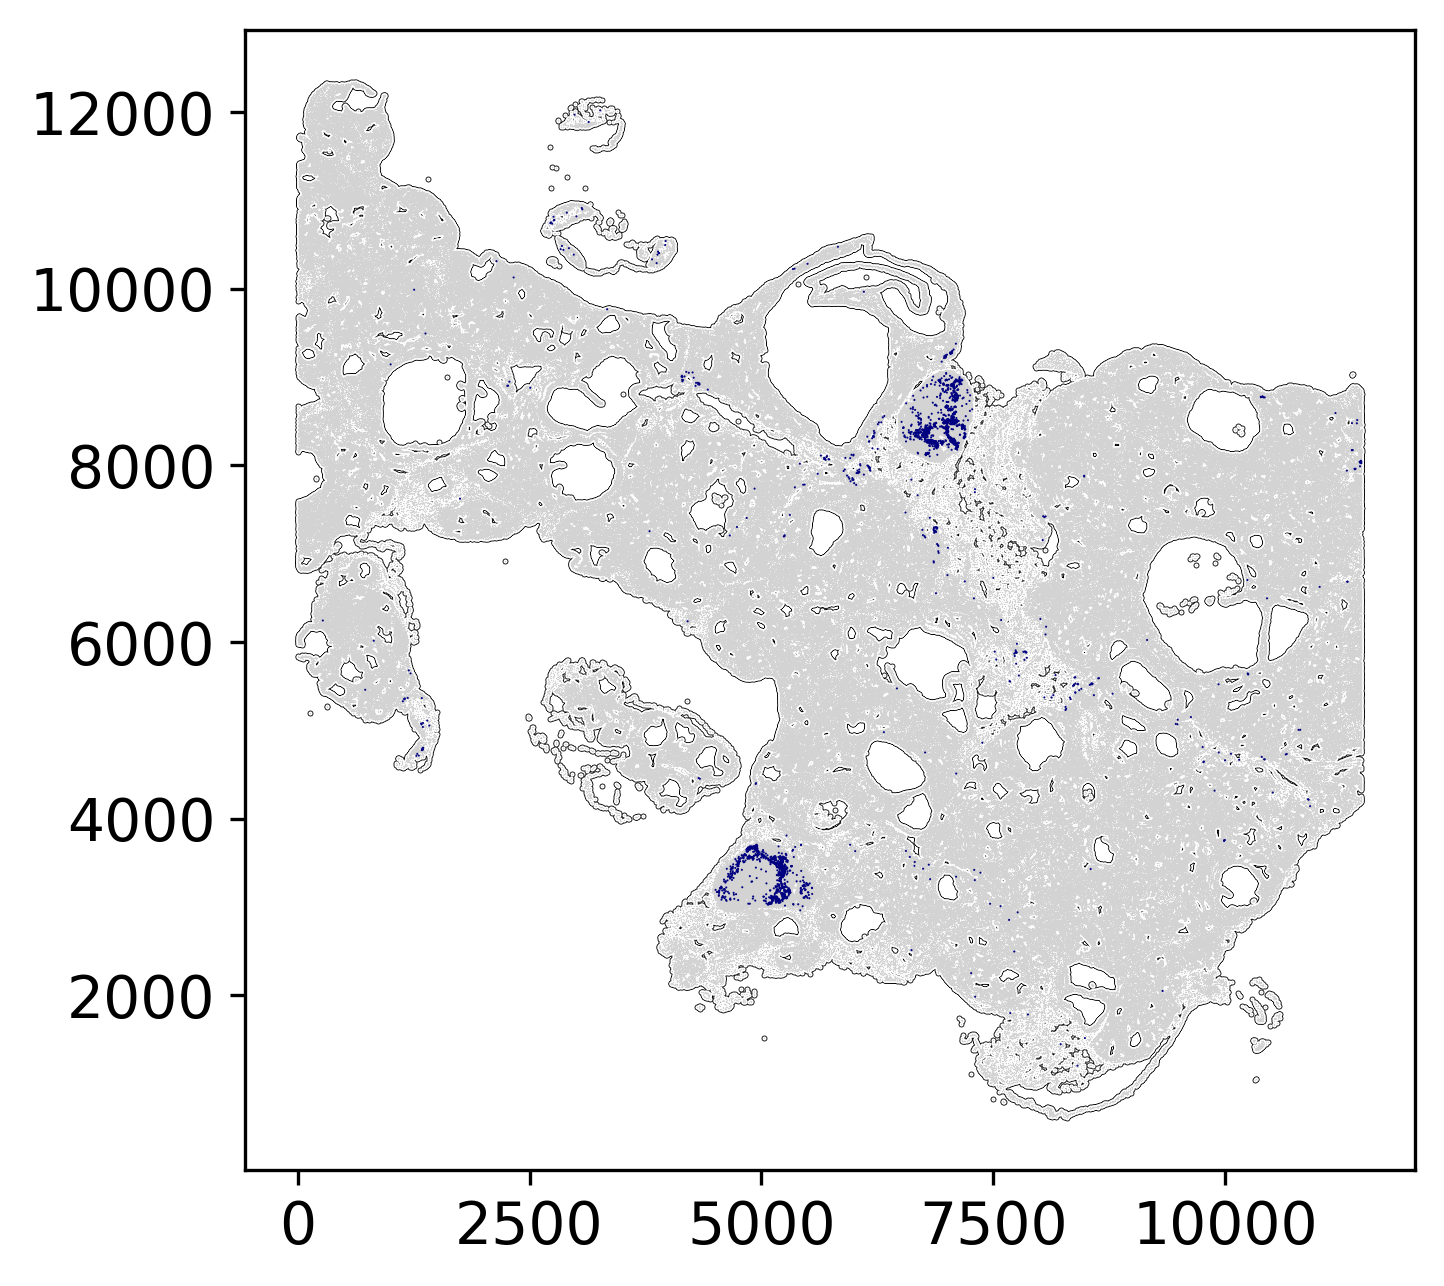

In [ ]:
plot_individual_category(adata_sub, "X_spatial", "cell_type_1", ["plasma"], ["navy", "red", "limegreen"])

In silico dissect lymph nodes

In [ ]:
def get_lymph_node_ids(adata_sub, selected_radius = 30, min_cells_per_node = 250):
    lymph_cell_types = ['B', 'B_cycling', 'plasma', 'Immune_B', 'T_CD4', 'T_CD8', 'T_cycling']
    adata_lymph = adata_sub[ismember(adata_sub.obs['cell_type_1'], lymph_cell_types)[1],:].copy()
    neighbor_graph = radius_neighbors_graph(adata_lymph.obsm['X_spatial'], radius = selected_radius)
    connected_components = scipy.sparse.csgraph.connected_components(neighbor_graph)[1]
    component_freq = pd.Series(connected_components).value_counts()
    lymph_component = component_freq.index[component_freq >= min_cells_per_node].to_numpy()
    return(adata_lymph.obs_names[ismember(connected_components, lymph_component)[1]])

In [ ]:
unique_samples = np.unique(adata_all.obs['slide_id'])
all_lymph_cells = np.array([False] * adata_all.n_obs)
for my_sample in tqdm(unique_samples):
    valid_cells = adata_all.obs['slide_id'].to_numpy() == my_sample
    adata_sub = adata_all[valid_cells,:].copy()
    spatial_neighborhood = adata_neighborhood.obsp['spatial_neighborhood'][valid_cells,:].copy()[:,valid_cells].copy()
    lymph_cells = get_lymph_node_ids(adata_sub)
    if len(lymph_cells) > 0:
        all_lymph_cells[ismember(lymph_cells, adata_all.obs_names.to_numpy())[0]] = True

100%|██████████| 33/33 [02:08<00:00,  3.89s/it]


In [ ]:
adata_all.obs['lymph_node_cells'] = pd.Categorical(np.ravel(adata_neighborhood.obsp['spatial_neighborhood'][all_lymph_cells,:].sum(axis=0)) > 0)

In [ ]:
valid_cells = adata_all.obs['slide_id'] == 'JR-sp-15-09'
adata_sub = adata_all[valid_cells,:].copy()

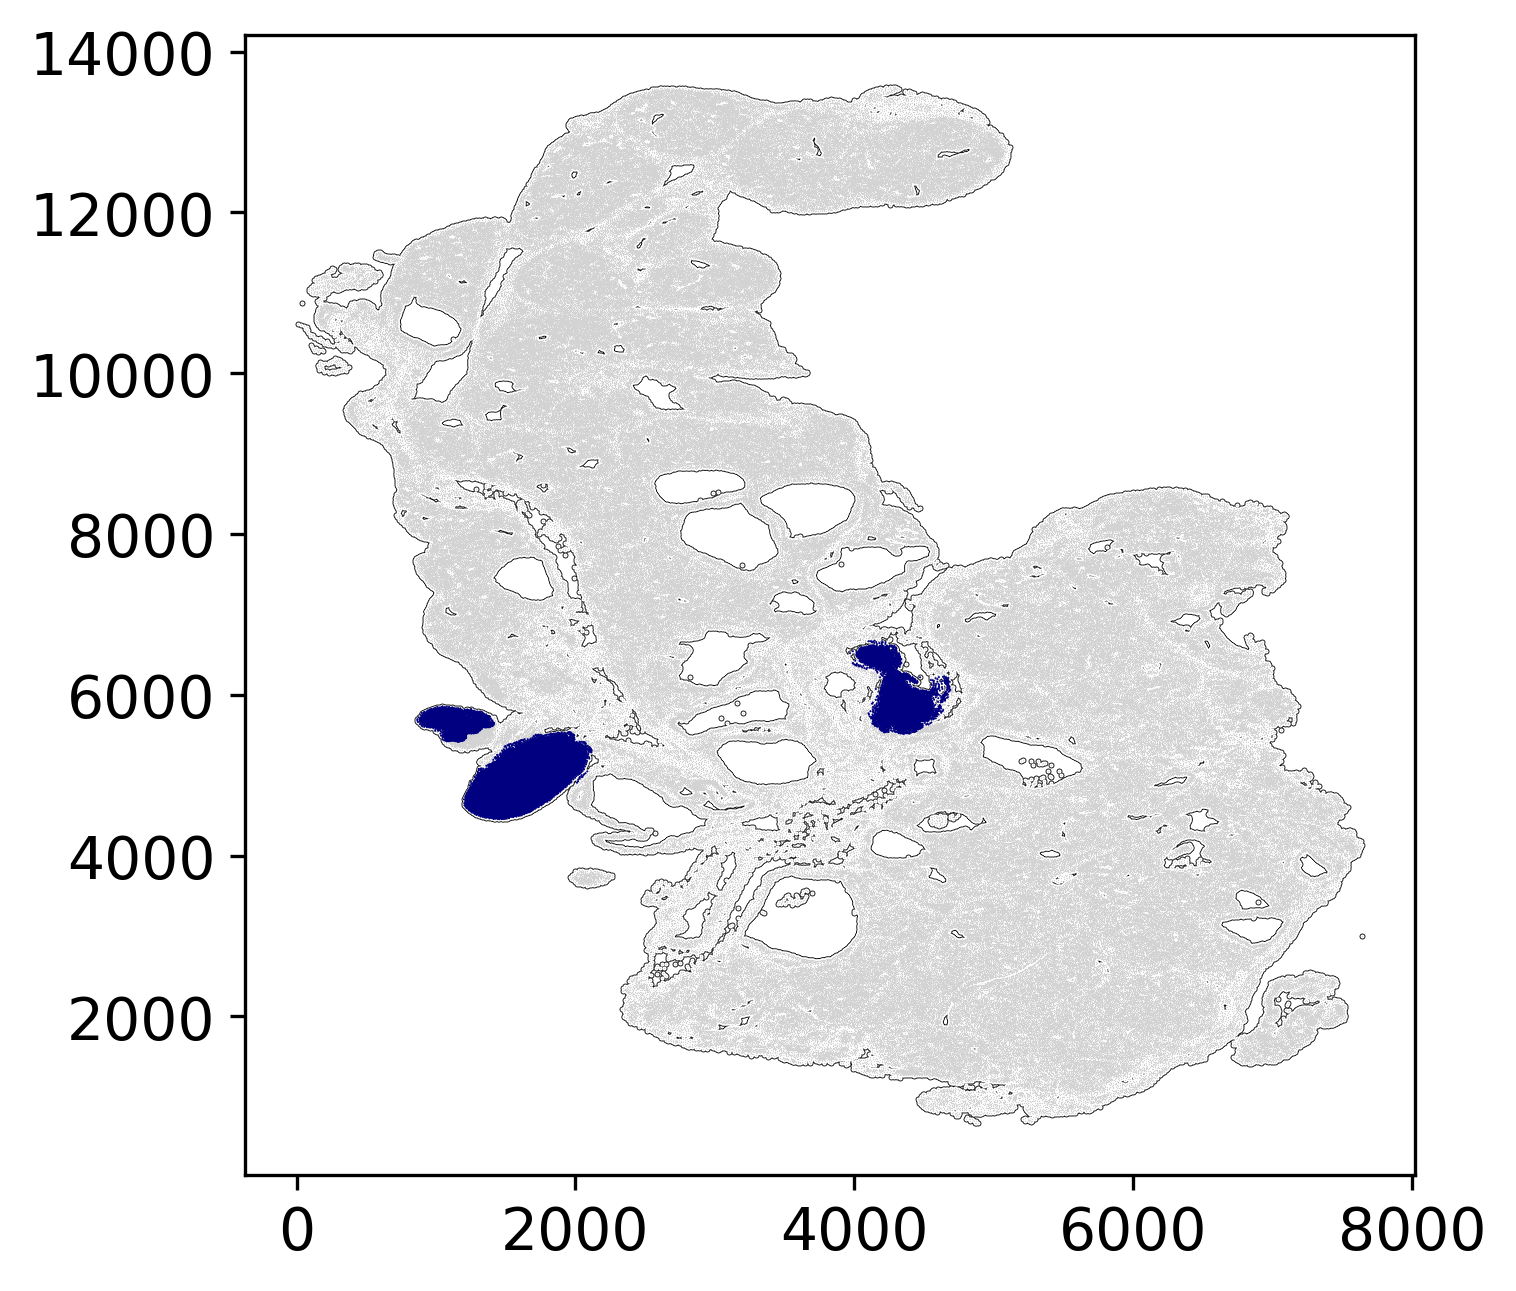

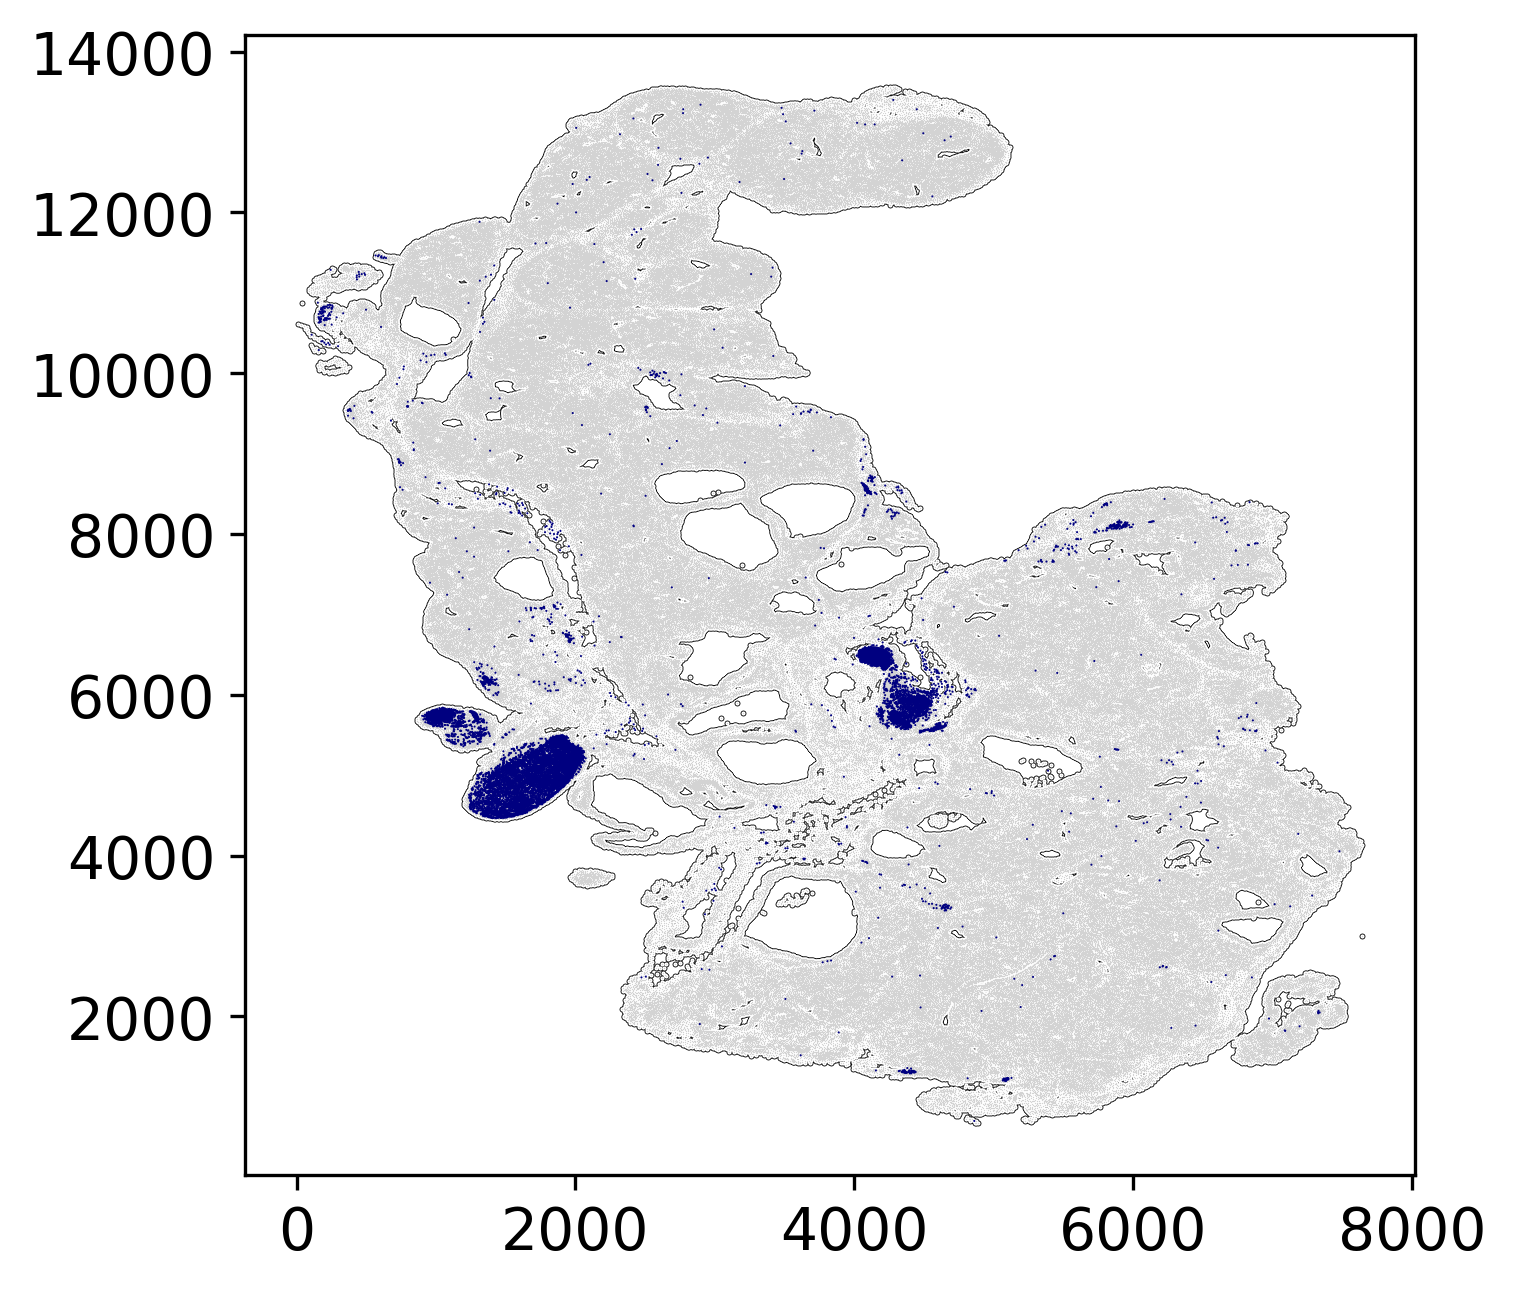

In [ ]:
plot_individual_category(adata_sub, "X_spatial", "lymph_node_cells", [True], ["navy"])
plot_individual_category(adata_sub, "X_spatial", "cell_type_0", ["Immune_B"], ["navy"])

Write master annotations file

In [ ]:
print("Loading master annotations")
master_obs_file = os.path.join(updated_obs_output_path, "adata_tier0_SUBSET_all_LAYER_raw_in_nucleus_LOG_False_EXPLAINEDVAR_75_KNN_30__obs.h5ad")
master_obs = sc.read_h5ad(master_obs_file)
master_obs = master_obs[adata_all.obs_names,:].copy()

Loading master annotations


In [ ]:
master_obs.obs = adata_all.obs.copy()

In [ ]:
sc.write(master_obs_file, adata = master_obs)